# 🧪 Notebook 14: Predição Dinâmica Diária (Experimental)

Neste notebook, expandimos a lógica do Notebook 13 para utilizar **Margens Dinâmicas** e **Pesos de Ensemble Variáveis** por dia da semana.

**Diferenciais:**
1. **Monte Carlo por Dia**: O desvio padrão do erro é calculado especificamente para cada dia da semana.
2. **Hibridismo Ajustado**: Pesos IA vs Reserva variam conforme a volatilidade histórica do dia.

# Metodologia Design Science Research (DSR) - NB14

## 1. Problema e Motivação
A variação cíclica da acurácia do modelo ao longo da semana, onde certos dias apresentam maior incerteza inerente (ex: sextas-feiras ou dias de cardápio especial).

## 2. Objetivos da Solução
Refinar o artefato de predição introduzindo margens de segurança e pesos de ensemble que se adaptam dinamicamente ao dia da semana.

## 3. Design e Desenvolvimento
Implementação de um simulador de Monte Carlo que utiliza o desvio padrão do erro específico de cada dia da semana para gerar bandas de confiança personalizadas (95%).

## 4. Demonstração
Demonstração de como a meta de produção "Segura" protege a operação contra faltas (Stockout) em dias historicamente instáveis, ajustando a gordura técnica de forma granular.

## 5. Avaliação
Validação da redução do risco operacional através da análise de cobertura (quantos dias o realizado ficou dentro da banda de confiança proposta).


In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "../data/"
INPUT_PATH = os.path.join(BASE_PATH, "predicao/")
print('✅ Motor 14 inicializado com Lógica Dinâmica Diária.')

✅ Motor 14 inicializado com Lógica Dinâmica Diária.


In [2]:
try:
    xlsx_files = glob.glob(os.path.join(INPUT_PATH, "*.xlsx"))
    csv_output = os.path.join(INPUT_PATH, "reservas_consolidadas_predicao.csv")

    if xlsx_files:
        latest_xlsx = max(xlsx_files, key=os.path.getmtime)
        if not os.path.exists(csv_output) or os.path.getmtime(latest_xlsx) > os.path.getmtime(csv_output):
            print("🛑 ERRO: Execute o 'Notebook 12' para processar o Excel novo.")
            raise InterruptedError("Anonimização pendente.")

    df_input_raw = pd.read_csv(csv_output)
    df_input_raw["data"] = pd.to_datetime(df_input_raw["data"])
    
    # AGREGAR POR DATA para a predição (total_reservas)
    df_input = df_input_raw.groupby("data").size().reset_index(name="total_reservas")
    
    print(f"📂 Dados carregados: {len(df_input)} dias de reservas identificados.")

    # Carregar base de treino para o Ensemble
    df_train_full = pd.read_csv(os.path.join(BASE_PATH, "base_features_selecionadas.csv"))
    df_train_full["data"] = pd.to_datetime(df_train_full["data"])
    
    # Carregar Embeddings BERT
    df_bert = pd.read_csv(os.path.join(BASE_PATH, "embeddings_bert_cardapio.csv"))
    df_bert["data"] = pd.to_datetime(df_bert["data"])
    
    # Merge nos dados de treino
    df_train_full = pd.merge(df_train_full, df_bert, on="data", how="inner")
    
    shadow_mask = df_input["data"].isin(df_train_full["data"])
    IS_SHADOWING = shadow_mask.any()

    df_cardapio = pd.read_csv(os.path.join(BASE_PATH, "cardapio_consolidado.csv"))
    df_cardapio["data"] = pd.to_datetime(df_cardapio["data"])
    
    missing = df_input[~df_input["data"].isin(df_cardapio["data"])]
    if not missing.empty:
        print("🛑 ALERTA: Faltam pratos no cardápio!")
        for d in missing["data"]: print(f"- {d.strftime('%d/%m/%Y')}")
        HAS_ERROR = True
    else:
        HAS_ERROR = False

except Exception as e:
    print(f"❌ Erro: {e}")
    HAS_ERROR = True

📂 Dados carregados: 1 dias de reservas identificados.


In [3]:
if 'HAS_ERROR' in locals() and not HAS_ERROR:
    print('🧠 Treinando Comitê Preditivo (XGB + LGBM + CAT)... Lógica Dinâmica Diária...')
    TARGET = 'total_servido' if 'total_servido' in df_train_full.columns else 'servida'
    
    features = [c for c in df_train_full.columns if c not in [TARGET, 'data', 'base_servida', 'reserva', 'total_reservas']]
    
    m_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
    m_lgb = LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1, importance_type='gain')
    m_cat = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=6, verbose=0, random_state=42)
    
    X_train = df_train_full[features]
    y_train = df_train_full[TARGET]
    
    m_xgb.fit(X_train, y_train)
    m_lgb.fit(X_train, y_train)
    m_cat.fit(X_train, y_train)
    
    # --- CÁLCULO DE RESÍDUOS POR DIA DA SEMANA ---
    print('📊 Analisando volatilidade por dia da semana...')
    p_ml_train = (m_xgb.predict(X_train) + m_lgb.predict(X_train) + m_cat.predict(X_train)) / 3
    
    # Tabela de pesos dinâmicos (Experimental)
    # 0=Seg, 1=Ter, 2=Qua, 3=Qui, 4=Sex
    dict_pesos = {
        0: {'ia': 0.75, 'res': 0.25}, # Segundas: IA é forte
        1: {'ia': 0.75, 'res': 0.25}, # Terças: Estável
        2: {'ia': 0.70, 'res': 0.30}, # Quartas: Feijoada (Reserva importa mais)
        3: {'ia': 0.70, 'res': 0.30}, # Quintas
        4: {'ia': 0.60, 'res': 0.40}  # Sextas: Dia de Peixe/Evento (Alta volatilidade)
    }
    
    for dia in range(5):
        mask = df_train_full['dia_semana'] == dia
        if mask.any():
            p_dia = p_ml_train[mask]
            res_dia = y_train[mask] - ((dict_pesos[dia]['ia'] * p_dia) + (dict_pesos[dia]['res'] * df_train_full[mask]['total_reservas']))
            std_dia = np.std(res_dia)
            dict_pesos[dia]['std'] = std_dia
            print('  > Dia {}: Erro Std = {:.1f} | Peso IA = {}'.format(dia, std_dia, dict_pesos[dia]['ia']))
        else:
            dict_pesos[dia]['std'] = np.std(y_train - p_ml_train) # Fallback global
    
    # --- INFERÊNCIA DINÂMICA ---
    df_infer = pd.merge(df_input, df_train_full[features + ['data']], on='data', how='left')
    
    if 'dia_semana_y' in df_infer.columns:
        df_infer = df_infer.rename(columns={'dia_semana_y': 'dia_semana'})
    if 'dia_semana' not in df_infer.columns:
        df_infer['dia_semana'] = df_infer['data'].dt.dayofweek
    
    for f in features:
        if f in df_infer.columns and df_infer[f].isnull().any():
            df_infer[f] = df_infer[f].fillna(df_train_full[f].median())

    preds_ml = (m_xgb.predict(df_infer[features]) + m_lgb.predict(df_infer[features]) + m_cat.predict(df_infer[features])) / 3
    
    # Aplicação de Pesos Variáveis
    def calc_pred_ia(row, p_ml):
        dia = int(row['dia_semana'])
        w = dict_pesos.get(dia, {'ia': 0.7, 'res': 0.3})
        return np.ceil((w['ia'] * p_ml) + (w['res'] * row['total_reservas']))

    df_infer['Predição IA'] = [calc_pred_ia(row, p) for row, p in zip(df_infer.to_dict('records'), preds_ml)]
    
    # --- Monte Carlo Dinâmico ---
    print('🎲 Gerando Margem de Segurança Monte Carlo DINÂMICA...')
    
    def simulate_margin_dynamic(row):
        dia = int(row['dia_semana'])
        std_dia = dict_pesos.get(dia, {'std': 15})['std']
        sims = np.random.normal(row['Predição IA'], std_dia, 5000)
        return np.percentile(np.maximum(sims, 0), 95)
    
    df_infer['Meta Cozinha (Segurança)'] = df_infer.apply(lambda x: np.ceil(simulate_margin_dynamic(x)), axis=1)
    df_infer['Meta Cozinha'] = np.ceil(df_infer['Predição IA'] * 1.12)
    
    print('✅ Predição Dinâmica Diária concluída.')

🧠 Treinando Comitê Preditivo (XGB + LGBM + CAT)... Lógica Dinâmica Diária...


📊 Analisando volatilidade por dia da semana...
  > Dia 0: Erro Std = 11.0 | Peso IA = 0.75
  > Dia 1: Erro Std = 10.4 | Peso IA = 0.75
  > Dia 2: Erro Std = 9.2 | Peso IA = 0.7
  > Dia 3: Erro Std = 14.2 | Peso IA = 0.7
  > Dia 4: Erro Std = 11.6 | Peso IA = 0.6


🎲 Gerando Margem de Segurança Monte Carlo DINÂMICA...
✅ Predição Dinâmica Diária concluída.


📊 AUDITORIA DE PRECISÃO (Ensemble Híbrido): Erro Médio de 33.0 refeições


,data,total_reservas,total_servido,Predição IA,Meta Cozinha (Segurança)
0,2025-08-22,191,111,144.0,164.0


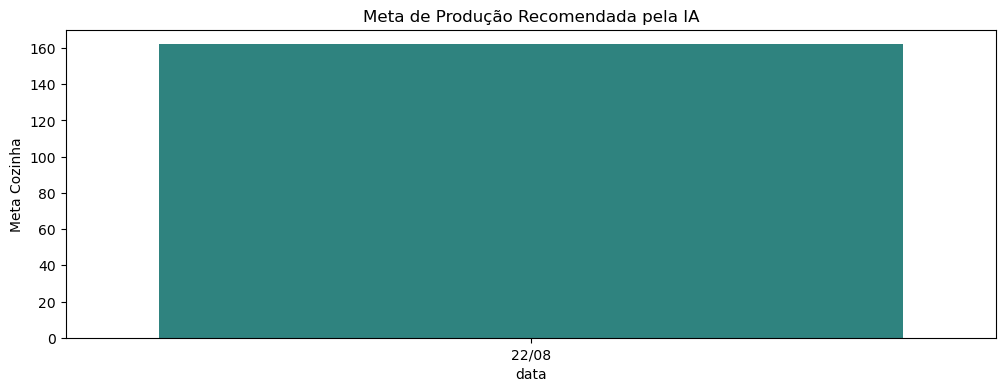

In [4]:
if "df_infer" in locals() and not HAS_ERROR:
    if IS_SHADOWING:
        target = "total_servido" if "total_servido" in df_train_full.columns else "servida"
        df_eval = pd.merge(df_infer, df_train_full[["data", target]], on="data")
        mae = mean_absolute_error(df_eval[target], df_eval["Predição IA"])
        print(f"📊 AUDITORIA DE PRECISÃO (Ensemble Híbrido): Erro Médio de {mae:.1f} refeições")
        display(df_eval[["data", "total_reservas", target, "Predição IA", "Meta Cozinha (Segurança)"]])
    else:
        print("🔮 RECOMENDAÇÃO FUTURA (Baseada em Comitê de IA Profissional):")
        display(df_infer[["data", "total_reservas", "Predição IA", "Meta Cozinha", "Meta Cozinha (Segurança)"]])
        
    plt.figure(figsize=(12, 4))
    sns.barplot(x=df_infer["data"].dt.strftime("%d/%m"), y=df_infer["Meta Cozinha"], palette="viridis")
    plt.title("Meta de Produção Recomendada pela IA"); plt.show()